# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
# libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#load data and convert into dataframe
housing = fetch_california_housing()
df = pd.DataFrame(housing.data,columns=housing.feature_names)
df['PRICES'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICES
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.shape

(20640, 9)

In [4]:

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICES
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICES      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


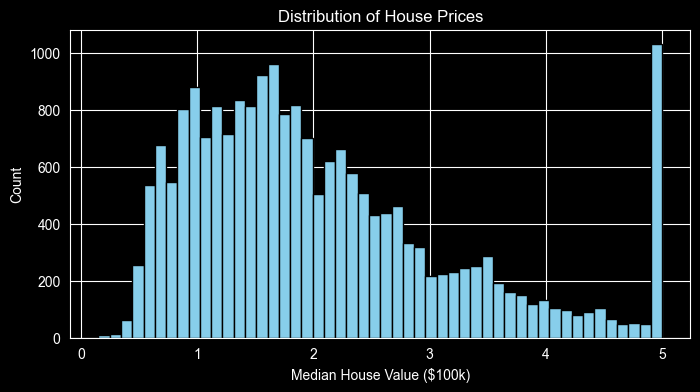

In [6]:
#visualization
plt.figure(figsize=(8,4))
plt.hist(df['PRICES'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Count')
plt.show()

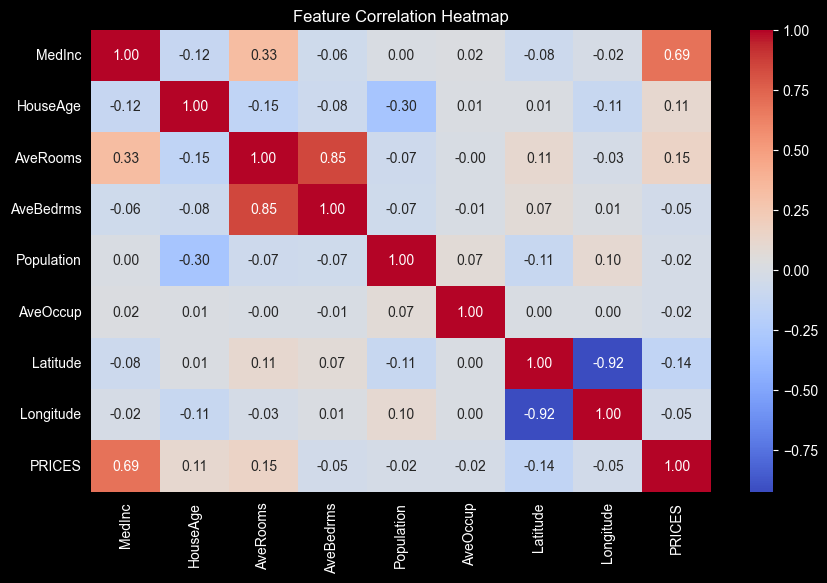

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

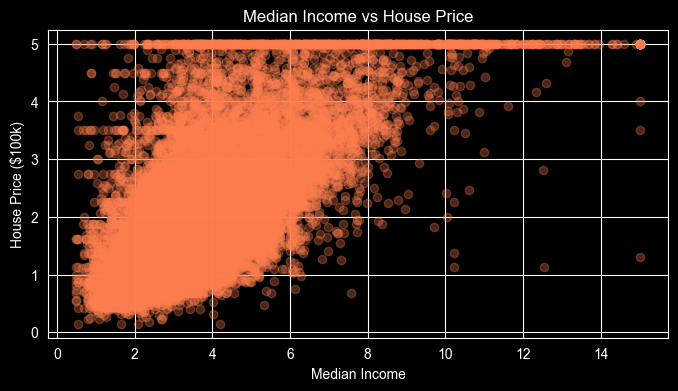

In [8]:
plt.figure(figsize=(8,4))
plt.scatter(df['MedInc'], df['PRICES'], alpha=0.3, color='coral')
plt.title('Median Income vs House Price')
plt.xlabel('Median Income')
plt.ylabel('House Price ($100k)')
plt.show()

In [9]:
#train and test
X = df.drop('PRICES', axis=1)
y = df['PRICES']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (16512, 8)
Testing size: (4128, 8)


In [13]:
#model selection and training
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("First 5 predictions:", y_pred[:5].round(2))
print("First 5 actual values:", y_test[:5].values)

First 5 predictions: [0.72 1.76 2.71 2.84 2.6 ]
First 5 actual values: [0.477   0.458   5.00001 2.186   2.78   ]


In [14]:
#metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Evaluation Results:")
print(f"MAE  (Mean Absolute Error):  {mae:.4f}")
print(f"MSE  (Mean Squared Error):   {mse:.4f}")
print(f"RMSE (Root Mean Sq. Error):  {rmse:.4f}")
print(f"R²   (R-Squared Score):      {r2:.4f}")

Evaluation Results:
MAE  (Mean Absolute Error):  0.5332
MSE  (Mean Squared Error):   0.5559
RMSE (Root Mean Sq. Error):  0.7456
R²   (R-Squared Score):      0.5758


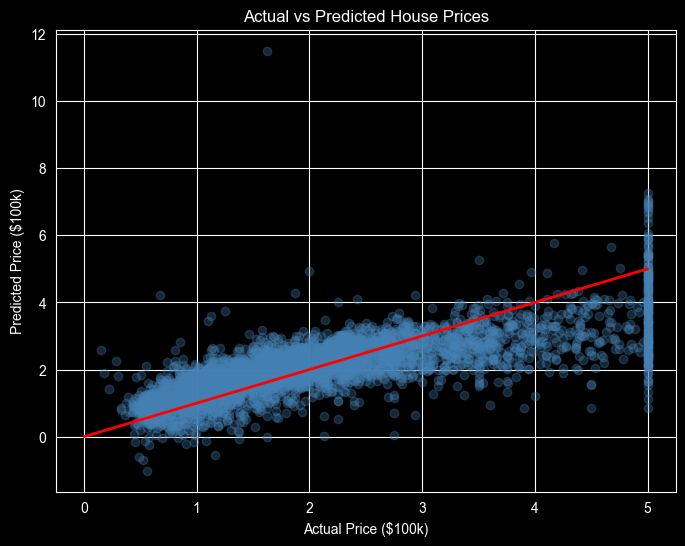

In [12]:
#plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([0, 5], [0, 5], color='red', linewidth=2)  # perfect prediction line
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price ($100k)')
plt.ylabel('Predicted Price ($100k)')
plt.show()

points far from redline = bad predicitions and near= good